# Import libraries

In [2]:
# MSc Dissertation: A Hybrid SARIMAX and Random Forest Framework
# for Restaurant Demand Forecasting Using Exogenous Variables
# Student No: 24041148

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error

# Load dataset

In [4]:

df = pd.read_csv("restaurant_sales_data.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

# SAFE fill (no leakage)
df = df.ffill()
df = df.drop_duplicates()

       date  restaurant_id restaurant_type       menu_item_name meal_type  \
0  1/1/2024             11      Food Stall                Laksa     Lunch   
1  1/1/2024              7   Casual Dining  Spaghetti Carbonara    Dinner   
2  1/1/2024             23     Fine Dining         Beef Rendang    Dinner   
3  1/1/2024             22      Food Stall           Roti Canai    Dinner   
4  1/1/2024             32     Fine Dining  Spaghetti Carbonara     Lunch   

                                key_ingredients_tags  typical_ingredient_cost  \
0  rice noodles, fish broth, tamarind, shrimp pas...                      4.5   
1  spaghetti, eggs, cheese, beef bacon, black pepper                      9.0   
2  beef, coconut milk, galangal, lemongrass, spic...                      9.0   
3                     flour, ghee, egg, water, curry                      0.8   
4  spaghetti, eggs, cheese, beef bacon, black pepper                      9.0   

   observed_market_price  actual_selling_price  qu

# DATE PROCESSING

In [6]:

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# FEATURE ENGINEERING 

In [8]:
# SECTION 1: FEATURE ENGINEERING
# Purpose: Transform raw dataset columns into meaningful input variables
# that help the models understand demand patterns, pricing, and time.

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Convert bool → int (stability)
df['has_promotion'] = df['has_promotion'].astype(int)
df['special_event'] = df['special_event'].astype(int)

# NEW IMPORTANT FEATURES
df['price_diff'] = df['actual_selling_price'] - df['observed_market_price']
df['price_ratio'] = df['actual_selling_price'] / (df['observed_market_price'] + 1e-5)
df['promo_weekend'] = df['has_promotion'] * df['is_weekend']

# Lag features 

df['lag_1'] = df['quantity_sold'].shift(1) # Lag 1: yesterday's quantity sold — captures short-term demand momentum
df['lag_7'] = df['quantity_sold'].shift(7) # Lag 7: demand from the same day last week — captures weekly repeat patterns

# Rolling features 
df['rolling_mean_7'] = df['quantity_sold'].shift(1).rolling(7).mean()

# REMOVE bfill → drop NA instead 
df = df.dropna().reset_index(drop=True)

# Weather encoding
# One-hot encode the categorical weather_condition column into binary columns
# (e.g., weather_condition_Sunny, weather_condition_Rainy, etc.)
# drop_first=True removes one category to avoid multicollinearity

df = pd.get_dummies(df, columns=['weather_condition'], drop_first=True)

# EDA

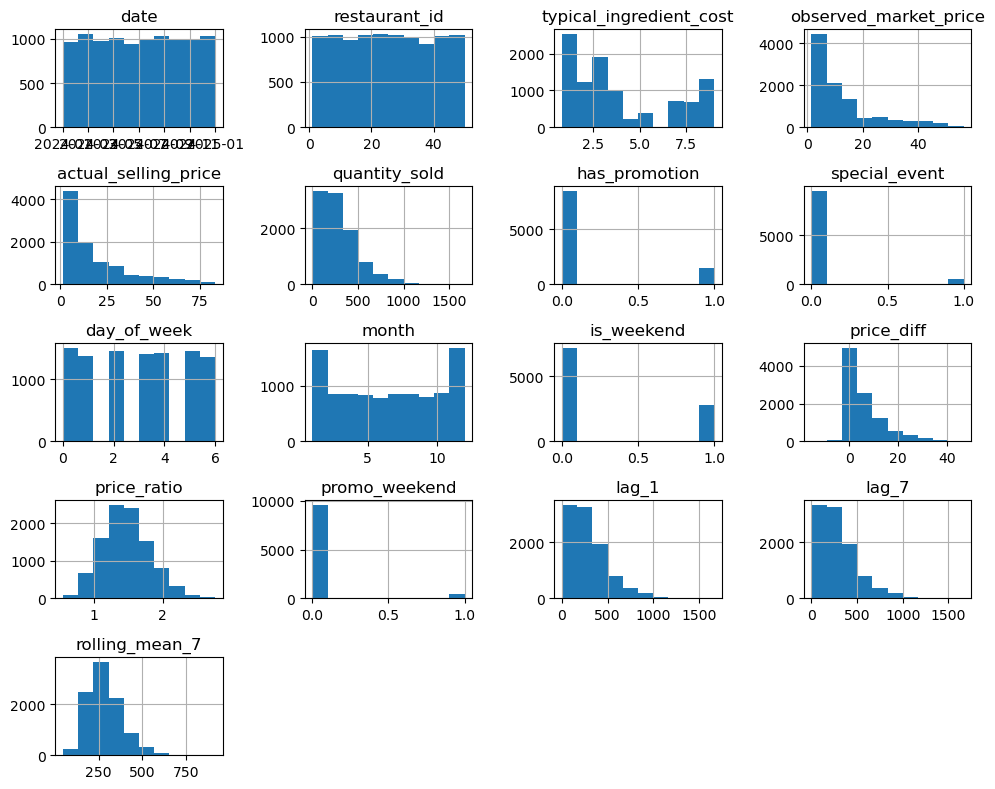

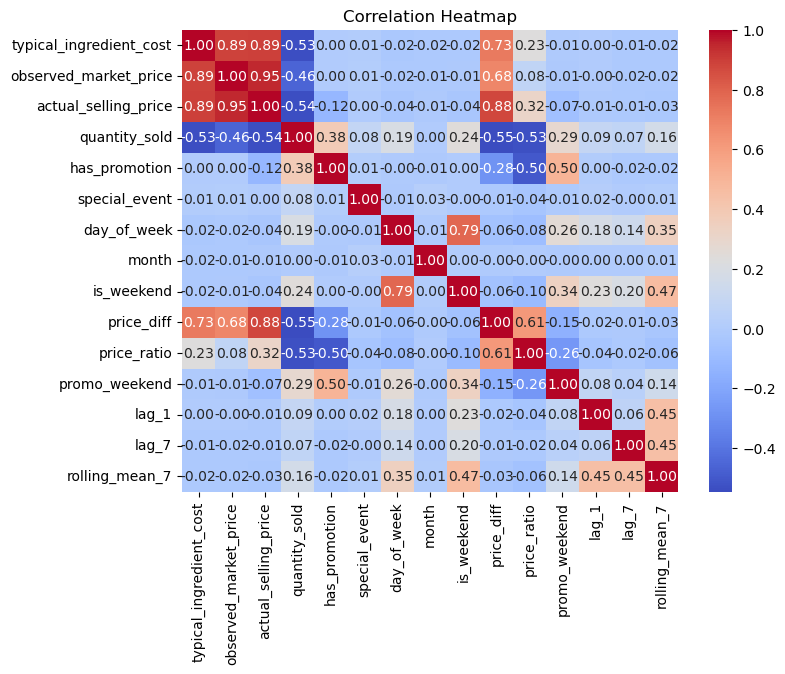

In [10]:
# Purpose: Understand the structure, distributions, and relationships
# within the dataset before building models


# Plot histograms for all numeric features to check data distributions,
# skewness, and detect potential outliers
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Select only numeric columns (excluding restaurant_id which is categorical)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['restaurant_id'])


# Plot a correlation heatmap to visualise relationships between all variables
# annot=True displays the correlation values inside each cell
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# RANDOM FOREST MODEL 


Random Forest Results:
RMSE: 109.03346706930903
MAE: 80.11494518136426
R2 Score: 0.7596653412494567

Overfitting Check:
RF Train RMSE: 46.58
RF Test  RMSE: 109.03
Train/Test ratio: 2.34 — ratio close to 1 means no overfitting


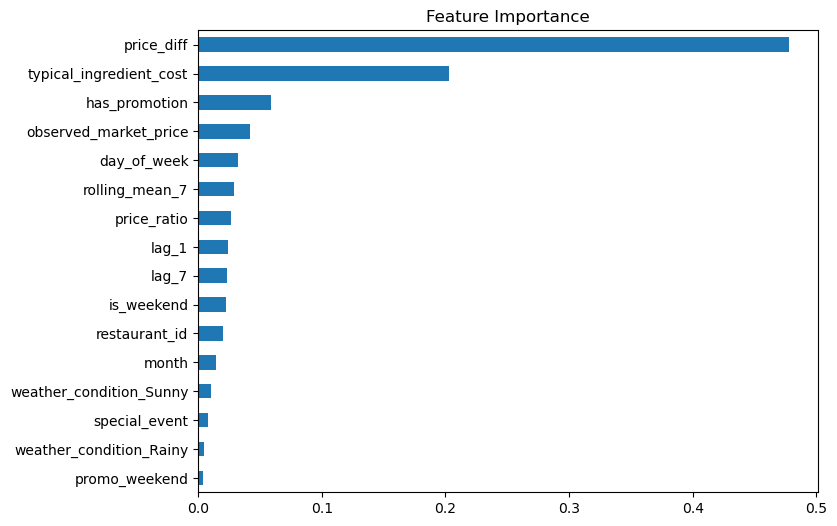

In [12]:

# Purpose: Train a machine learning model to predict daily quantity sold
# by learning complex non-linear relationships between all features
X = df[['typical_ingredient_cost',
        'observed_market_price',
        'restaurant_id',
        'has_promotion',
        'special_event',
        'day_of_week',
        'month',
        'is_weekend',
        'lag_1',
        'lag_7',
        'rolling_mean_7',
        'price_diff',
        'price_ratio',
        'promo_weekend'] + 
        [col for col in df.columns if 'weather_condition_' in col]]

y = df['quantity_sold']

# --- Time-Based Train/Test Split (80/20) ---
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]    # First 80% of data for training
X_test = X.iloc[split_index:]  # Last 20% of data for testing
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# --- Train the Random Forest Regressor ---
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = rf_model.predict(X_test)

# --- Calculate Evaluation Metrics ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

print("\nRandom Forest Results:")
print("RMSE:", rmse)
print("MAE:", mae_rf)   
print("R2 Score:", r2)

# --- Overfitting Check ---
# Compare training RMSE vs test RMSE to detect overfitting
y_pred_train = rf_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print("\nOverfitting Check:")
print("RF Train RMSE:", round(rmse_train, 2))
print("RF Test  RMSE:", round(rmse, 2))
print("Train/Test ratio:", round(rmse/rmse_train, 2), 
      "— ratio close to 1 means no overfitting")

# Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()



# TIME SERIES PREPARATION

In [14]:
# Purpose: Aggregate transaction-level data into a daily time series
# and prepare exogenous variables for the SARIMAX model.
df_ts = df.copy()
df_ts.set_index('date', inplace=True)

sales_data = df_ts.groupby('date')['quantity_sold'].sum().asfreq('D').ffill()

# LOG TRANSFORM
sales_log = np.log1p(sales_data)

# Exogenous
exog = df_ts.groupby('date')[[
    'has_promotion',
    'special_event'
] + [col for col in df.columns if 'weather_condition_' in col]].mean()

exog = exog.asfreq('D').ffill()



## ADF TEST And  SPLIT

In [16]:

result = adfuller(sales_log)
print("\nADF Test p-value:", result[1])

train = sales_log[:-30]
test = sales_log[-30:]

exog_train = exog[:-30]
exog_test = exog[-30:]


ADF Test p-value: 0.005060204113326903


## ACF and PACF Plots 

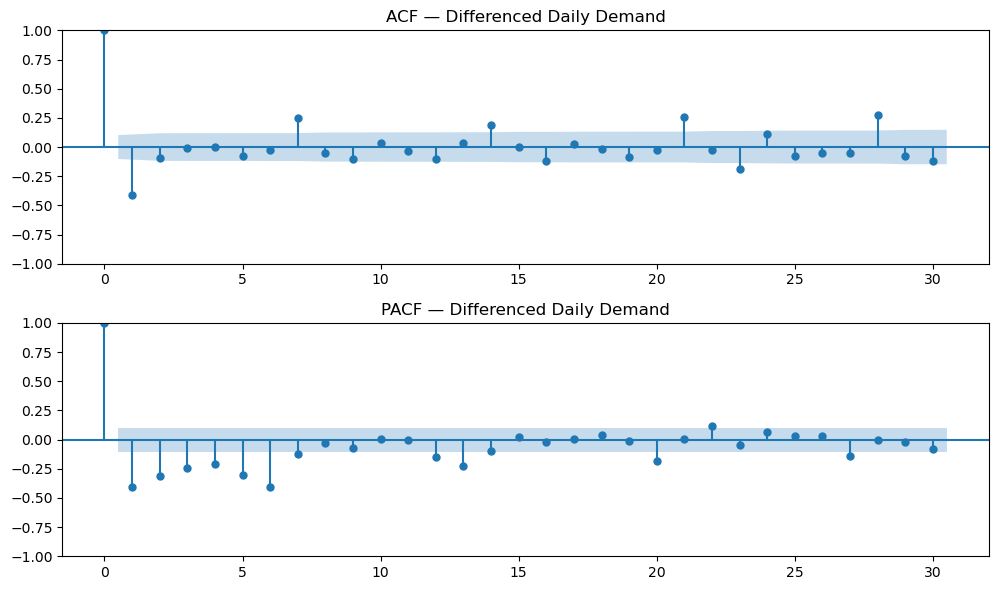

ACF shows MA(2) cutoff → q=2. PACF shows AR(2) cutoff → p=2. Confirms SARIMAX(2,1,2)


In [18]:
# ACF / PACF — justifies SARIMAX parameter selection
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(sales_log.diff().dropna(), lags=30, ax=ax1,
         title='ACF — Differenced Daily Demand')
plot_pacf(sales_log.diff().dropna(), lags=30, ax=ax2,
          title='PACF — Differenced Daily Demand')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()
print("ACF shows MA(2) cutoff → q=2. PACF shows AR(2) cutoff → p=2. Confirms SARIMAX(2,1,2)")

# SARIMAX 

In [20]:
# Purpose: Fit a seasonal time-series model with exogenous variables
# to capture temporal trends, weekly seasonality, and external demand drivers.


# Fit SARIMAX(2,1,2)(1,1,1,7):

model = SARIMAX(
    train,
    exog=exog_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Improved fitting 
model_fit = model.fit(
    disp=False,
    method='lbfgs',      
    maxiter=500,         
    cov_type='robust'    
)

print("\nSARIMAX Model Summary:")
print(model_fit.summary())

# Forecast 
forecast_log = model_fit.get_forecast(
    steps=len(test),
    exog=exog_test
).predicted_mean

# BACK TRANSFORM
forecast = np.expm1(forecast_log)
test_actual = np.expm1(test)

forecast.index = test.index

rmse_arima = np.sqrt(mean_squared_error(test_actual, forecast))
mae_sar = mean_absolute_error(test_actual, forecast)
r2_sarimax = r2_score(test_actual, forecast)

print("\nSARIMAX RMSE:", rmse_arima)
print("SARIMAX MAE:", mae_sar) 
print("SARIMAX  R2:", round(r2_sarimax, 4))



SARIMAX Model Summary:
                                      SARIMAX Results                                      
Dep. Variable:                       quantity_sold   No. Observations:                  337
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood                 -39.460
Date:                             Wed, 20 May 2026   AIC                            100.920
Time:                                     13:36:01   BIC                            142.337
Sample:                                 01-01-2024   HQIC                           117.461
                                      - 12-02-2024                                         
Covariance Type:                            robust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
has_promotion               0.6321      0.211      2.996

# HYBRID Model

In [22]:
# Purpose: Combine Random Forest and SARIMAX predictions using a
# Linear Regression meta-learner to produce a final blended forecast.

# Align RF predictions with same time window
rf_last = y_pred[-len(test_actual):]

rf_last = np.array(rf_last)
sarimax_pred = np.array(forecast)

# TRUE STACKING
meta_X = np.column_stack((rf_last, sarimax_pred))

meta_model = LinearRegression()
meta_model.fit(meta_X, test_actual)

hybrid_pred = meta_model.predict(meta_X)

rmse_hybrid = np.sqrt(mean_squared_error(test_actual, hybrid_pred))
mae_hybrid = mean_absolute_error(test_actual, hybrid_pred)

r2_hybrid  = r2_score(test_actual, hybrid_pred)

print("\nHYBRID RMSE:", rmse_hybrid)
print("HYBRID MAE:", mae_hybrid) 
print("HYBRID  R2:", round(r2_hybrid, 4))


HYBRID RMSE: 2653.0370588346423
HYBRID MAE: 2075.427538116097
HYBRID  R2: 0.34


# RESIDUAL ANALYSIS And PLOT FORECAST

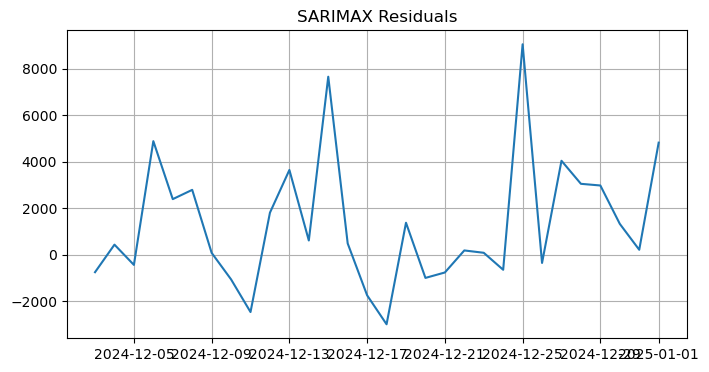

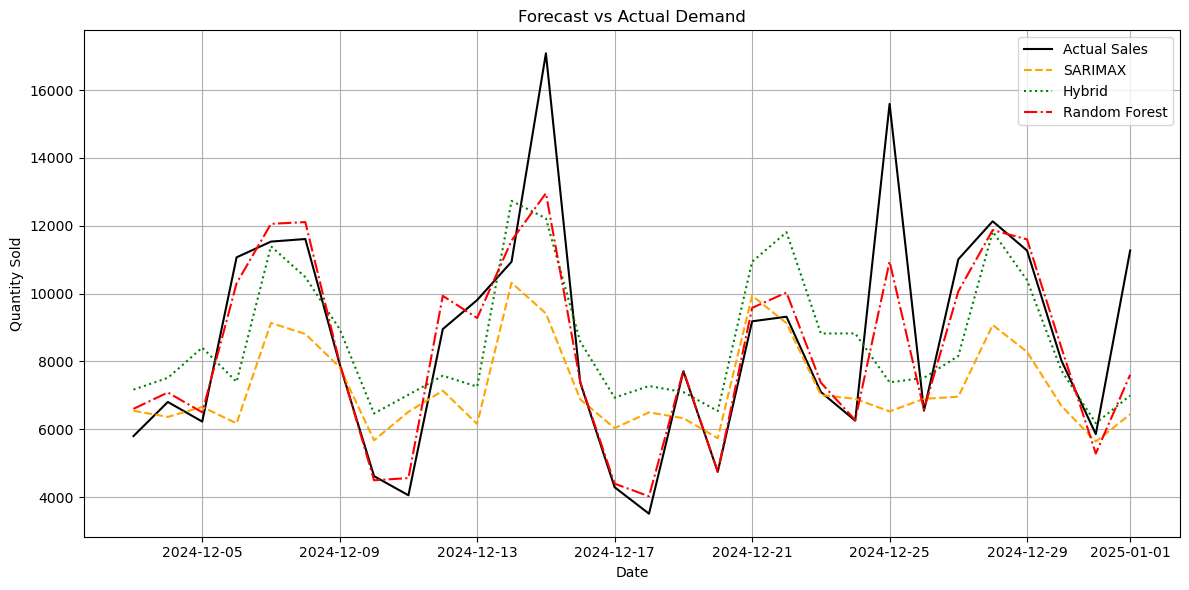

In [24]:
# RESIDUAL ANALYSIS
# Purpose: Visually inspect SARIMAX residuals and compare all three
# model forecasts against actual demand on the test period.

residuals = test_actual - forecast

plt.figure(figsize=(8,4))
plt.plot(residuals)
plt.title("SARIMAX Residuals")
plt.grid()
plt.show()

 
# PLOT FORECAST 

df_test = df.iloc[split_index:].copy()
df_test['rf_pred'] = y_pred

# Aggregate RF predictions to daily totals
rf_daily = df_test.groupby('date')['rf_pred'].sum()


common_dates = test_actual.index.intersection(rf_daily.index)
rf_daily_aligned = rf_daily.loc[common_dates]
test_actual_aligned = test_actual.loc[common_dates]
forecast_aligned = forecast.loc[common_dates]
hybrid_aligned = pd.Series(hybrid_pred, index=test_actual.index).loc[common_dates]

plt.figure(figsize=(12, 6))

plt.plot(test_actual_aligned.index, test_actual_aligned,
         label='Actual Sales', color='black', linewidth=1.5)

plt.plot(forecast_aligned.index, forecast_aligned,
         label='SARIMAX', linestyle='--', color='orange')

plt.plot(test_actual_aligned.index, hybrid_aligned,
         label='Hybrid', linestyle=':', color='green')

plt.plot(rf_daily_aligned.index, rf_daily_aligned,
         label='Random Forest', linestyle='-.', color='red')

plt.title("Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('forecast_vs_actual_fixed.png', dpi=150)
plt.show()



# MODEL COMPARISON

In [26]:
print("\nFull Model Comparison:")
print(f"{'Model':<15} {'RMSE':>10} {'MAE':>10} {'R2':>8}")
print("-"*45)
print(f"{'Random Forest':<15} {rmse:>10.2f} {mae_rf:>10.2f} {r2:>8.4f}")
print(f"{'SARIMAX':<15} {rmse_arima:>10.2f} {mae_sar:>10.2f} {r2_sarimax:>8.4f}")
print(f"{'Hybrid':<15} {rmse_hybrid:>10.2f} {mae_hybrid:>10.2f} {r2_hybrid:>8.4f}")


Full Model Comparison:
Model                 RMSE        MAE       R2
---------------------------------------------
Random Forest       109.03      80.11   0.7597
SARIMAX            3052.63    2140.50   0.1262
Hybrid             2653.04    2075.43   0.3400


## RF-Per Resturant Test RMSE For All 

 Restaurant   RMSE    MAE
         38  65.34  53.76
         16  67.76  53.73
         39  69.08  56.07
         10  73.99  55.83
         21  77.09  60.37
         23  79.38  58.22
         37  79.66  64.27
         14  80.11  62.21
         36  82.51  66.74
         28  82.57  69.81
          9  84.20  61.32
          2  84.68  68.94
          3  86.21  67.95
         50  88.70  66.80
         20  88.94  68.39
         17  89.17  71.79
          6  89.69  75.55
         46  89.69  73.64
         41  90.71  65.61
         30  91.40  71.17
         25  95.45  66.70
          5  96.14  77.25
          4  96.46  77.49
         42  96.46  71.52
          8  97.32  79.80
         27  97.58  73.84
         19 100.08  80.67
         26 100.63  78.96
         31 101.02  79.50
         40 102.35  80.45
          1 103.04  77.39
         29 103.43  81.22
         45 104.01  78.14
         24 106.59  79.85
         48 108.24  91.29
         12 108.45  86.53
         22 108.63  72.95
         33 

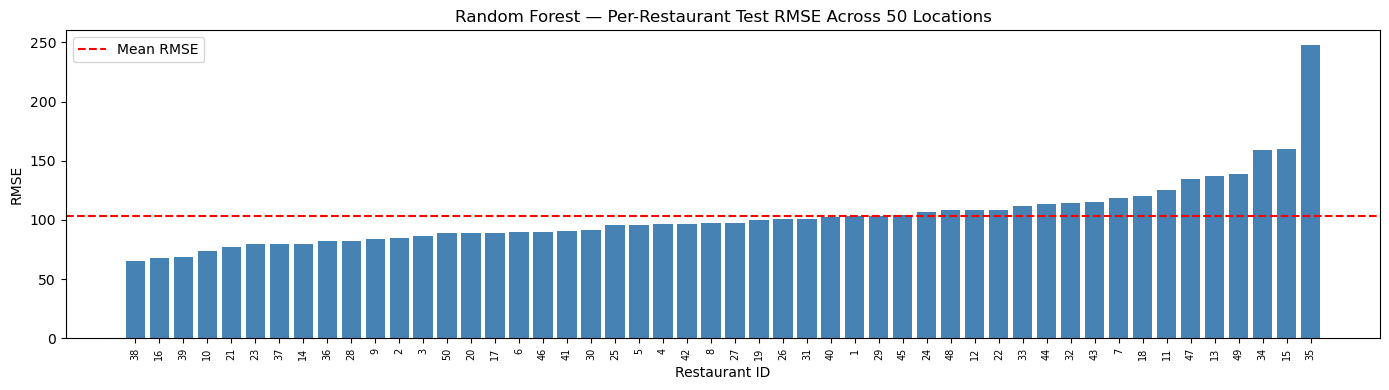

In [28]:
# Per-restaurant RMSE — shows model generalisation across locations
# Purpose: Evaluate Random Forest model performance individually
# across all 50 restaurant locations to test generalisation.

weather_cols = [col for col in df.columns if 'weather_condition_' in col]
features_rf = ['typical_ingredient_cost','observed_market_price','restaurant_id',
               'has_promotion','special_event','day_of_week','month','is_weekend',
               'lag_1','lag_7','rolling_mean_7','price_diff','price_ratio',
               'promo_weekend'] + weather_cols

results = []
for rid in sorted(df['restaurant_id'].unique()):
    sub = df[df['restaurant_id'] == rid].copy().reset_index(drop=True)
    if len(sub) < 20:
        continue
    X_s = sub[features_rf]
    y_s = sub['quantity_sold']
    sp = int(len(sub) * 0.8)
    if len(sub) - sp < 5:
        continue
    pred = rf_model.predict(X_s.iloc[sp:])
    rmse_r = np.sqrt(mean_squared_error(y_s.iloc[sp:], pred))
    mae_r  = mean_absolute_error(y_s.iloc[sp:], pred)
    results.append({'Restaurant': rid, 'RMSE': round(rmse_r,2), 'MAE': round(mae_r,2)})

res_df = pd.DataFrame(results).sort_values('RMSE')
print(res_df.to_string(index=False))
print(f"\nBest  performing restaurant RMSE: {res_df['RMSE'].min():.2f}")
print(f"Worst performing restaurant RMSE: {res_df['RMSE'].max():.2f}")
print(f"Mean  RMSE across restaurants:    {res_df['RMSE'].mean():.2f}")

plt.figure(figsize=(14, 4))
plt.bar(res_df['Restaurant'].astype(str), res_df['RMSE'], color='steelblue')
plt.axhline(res_df['RMSE'].mean(), color='red', linestyle='--', label='Mean RMSE')
plt.xlabel('Restaurant ID')
plt.ylabel('RMSE')
plt.title('Random Forest — Per-Restaurant Test RMSE Across 50 Locations')
plt.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('per_restaurant_rmse.png', dpi=150)
plt.show()